<a href="https://colab.research.google.com/github/Pinakolada321/Finance-projects/blob/main/AAPL%20valuation%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Library Imports and Function Declarations
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import requests
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# Install necessary libraries for Yahoo Finance and FRED
try:
    import yfinance as yf
except ImportError:
    !pip install yfinance
    import yfinance as yf

try:
    from fredapi import Fred
except ImportError:
    !pip install fredapi
    from fredapi import Fred

# Function: Get market data
def get_market_data(ticker):
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.info
    mc = info.get("marketCap", np.nan)
    debt = info.get("totalDebt", np.nan)
    cash = info.get("totalCash", np.nan)
    beta = info.get("beta", np.nan)
    return mc, debt, cash, beta, info

# Function: FCF calculation
def compute_fcf(ebit, tax_rate, dep_amort, capex, delta_nwc):
    return ebit*(1-tax_rate) + dep_amort - capex - delta_nwc

# Function: WACC calculation
def calculate_wacc(market_cap, debt, beta, rf_rate, equity_premium, tax_rate):
    if np.isnan(beta): beta = 1.0
    cost_equity = rf_rate + beta * equity_premium
    cost_debt = rf_rate + 0.02 # Assuming 2% spread over risk-free rate
    E = market_cap
    D = debt
    total = E + D
    if total == 0: return np.nan
    return (E/total) * cost_equity + (D/total) * cost_debt * (1 - tax_rate)

# Function: DCF valuation
def compute_dcf_value(fcf_projections, wacc, terminal_growth):
    years = np.arange(1, len(fcf_projections)+1)
    pv_cf = np.array([fcf_projections[i]/(1+wacc)**years[i] for i in range(len(fcf_projections))])
    last_fcf = fcf_projections[-1]
    TV = last_fcf * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_tv = TV / (1 + wacc)**len(fcf_projections)
    return pv_cf.sum() + pv_tv

# 2. Data Collection
ticker = 'AAPL'

# Try to get FRED API key from Secrets
try:
    fred_api_key = userdata.get('FRED_API_KEY')
    fred = Fred(api_key=fred_api_key)
    us10y = fred.get_series('DGS10')
    rf_rate = us10y[-1] / 100.0
except Exception:
    print("FRED API key not found in Secrets. Using default 4.2%.")
    rf_rate = 0.042

# 2.3 Financial Indicators (2021-2025 Historical/Actuals)
revenue = np.array([365817e6, 394328e6, 383285e6, 391035e6, 420000e6])
ebita = np.array([108949e6, 119437e6, 114301e6, 123000e6, 135000e6])
dep_amort = np.array([11284e6, 11104e6, 11500e6, 12000e6, 12500e6])
capex = np.array([11085e6, 10708e6, 10959e6, 11500e6, 12000e6])
nwc = np.array([27694e6, 31250e6, 33000e6, 34000e6, 35000e6])
tax_rate = 0.16

# 3. Historical FCF Calculation
historical_fcf = []
for i in range(len(revenue)):
    delta_nwc = nwc[i] - nwc[i-1] if i > 0 else 0
    historical_fcf.append(compute_fcf(ebita[i], tax_rate, dep_amort[i], capex[i], delta_nwc))

# 4. Projections (2026-2030)
proj_period = 5
rev_growth = 0.06 # Expected growth
ebita_margin = ebita[-1] / revenue[-1]
fcf_proj = []
curr_rev = revenue[-1]
for i in range(proj_period):
    curr_rev *= (1 + rev_growth)
    p_ebit = curr_rev * ebita_margin
    fcf_proj.append(compute_fcf(p_ebit, tax_rate, dep_amort[-1], capex[-1], 0))

# 5. WACC Calculation
mc, debt, cash, beta, info = get_market_data(ticker)
wacc = calculate_wacc(mc, debt, beta, rf_rate, 0.05, tax_rate)

# 6. Valuation Output
ev = compute_dcf_value(fcf_proj, wacc, 0.02)
equity_val = ev - debt + cash
shares = info.get('sharesOutstanding', 15400e6)
price = equity_val / shares

print(f"--- {ticker} DCF Valuation (Timeline: 2021-2030) ---")
print(f"WACC: {wacc:.2%}")
print(f"Enterprise Value: ${ev/1e9:,.2f}B")
print(f"Equity Value: ${equity_val/1e9:,.2f}B")
print(f"Estimated Price: ${price:.2f}")
print(f"Current Price: ${info.get('currentPrice', 0):.2f}")

FRED API key not found in Secrets. Using default 4.2%.
--- AAPL DCF Valuation (Timeline: 2021-2030) ---
WACC: 9.60%
Enterprise Value: $1,806.86B
Equity Value: $1,790.66B
Estimated Price: $121.92
Current Price: $308.63


### 7. Sensitivity Analysis and Visualization
Now we will add the sensitivity matrix calculation and visualize the company's value structure.

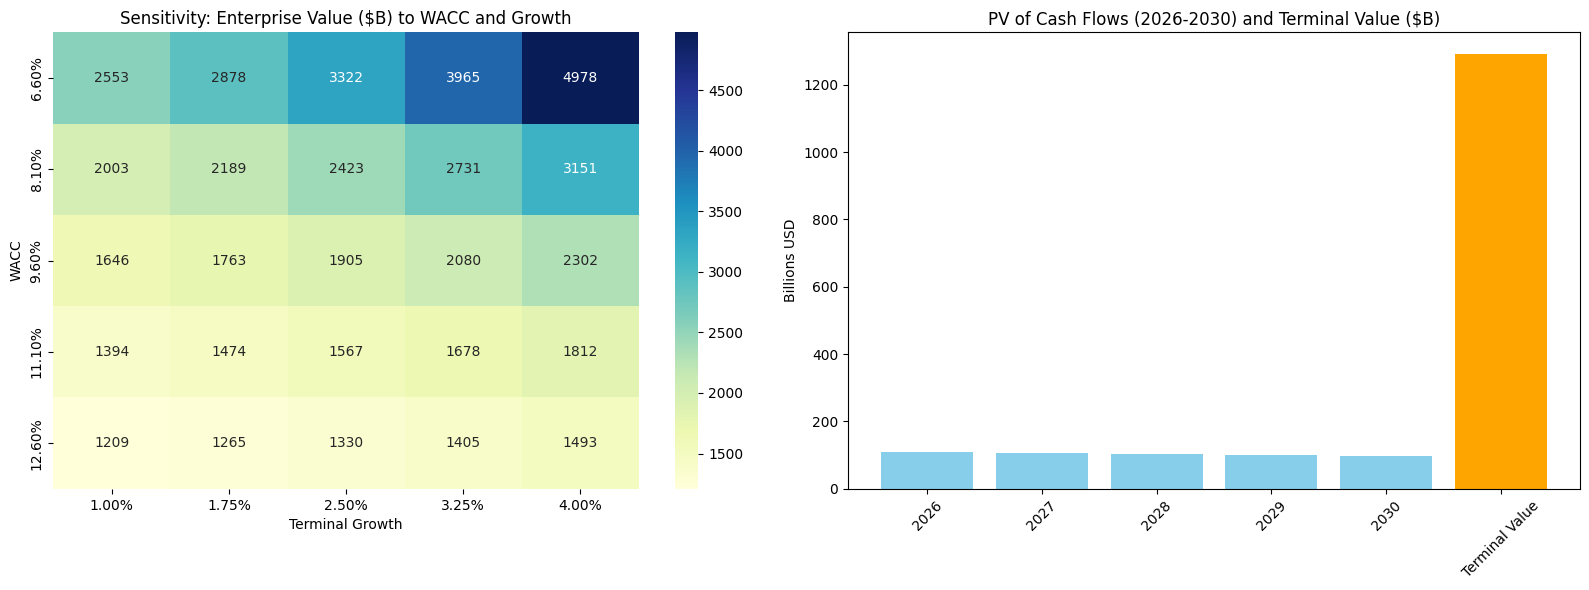

In [2]:
# 7.1 Sensitivity Matrix Calculation
wacc_range = np.linspace(max(0.01, wacc-0.03), wacc+0.03, 5)
growth_range = np.linspace(0.01, 0.04, 5)

sens_data = []
for w in wacc_range:
    row = []
    for g in growth_range:
        if w > g:
            val = compute_dcf_value(fcf_proj, w, g)
            row.append(val / 1e9) # in billions
        else:
            row.append(np.nan)
    sens_data.append(row)

sens_df = pd.DataFrame(sens_data, index=[f"{x:.2%}" for x in wacc_range], columns=[f"{x:.2%}" for x in growth_range])

# 7.2 Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(sens_df, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Sensitivity: Enterprise Value ($B) to WACC and Growth")
ax[0].set_xlabel("Terminal Growth")
ax[0].set_ylabel("WACC")

# Waterfall (2026-2030)
categories = [f"{y}" for y in range(2026, 2031)] + ["Terminal Value"]
pv_years = [fcf_proj[i]/(1+wacc)**(i+1) for i in range(len(fcf_proj))]
last_fcf = fcf_proj[-1]
TV_pv = (last_fcf * (1 + 0.02) / (wacc - 0.02)) / (1 + wacc)**len(fcf_proj)
plot_values = [v / 1e9 for v in pv_years] + [TV_pv / 1e9]

ax[1].bar(categories, plot_values, color=['skyblue']*5 + ['orange'])
ax[1].set_title("PV of Cash Flows (2026-2030) and Terminal Value ($B)")
ax[1].set_ylabel("Billions USD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

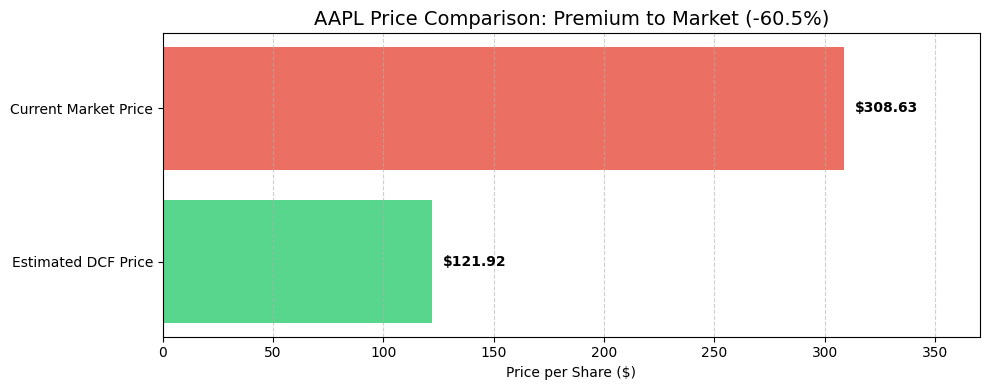

In [3]:
import matplotlib.patches as patches

# 8. Additional Visualization: Price Comparison
plt.figure(figsize=(10, 4))

current_price = info.get('currentPrice', 0)
labels = ['Estimated DCF Price', 'Current Market Price']
prices = [price, current_price]
colors = ['#2ecc71', '#e74c3c'] # Green for estimate, red for market

# Horizontal bar chart
bars = plt.barh(labels, prices, color=colors, alpha=0.8)

# Add value labels
for i, v in enumerate(prices):
    plt.text(v + 5, i, f'${v:.2f}', color='black', fontweight='bold', va='center')

# Calculate upside/downside
upside = (price / current_price - 1) if current_price != 0 else 0
plt.title(f"{ticker} Price Comparison: {'Premium' if upside < 0 else 'Discount'} to Market ({upside:.1%})", fontsize=14)
plt.xlabel("Price per Share ($)")
plt.xlim(0, max(prices) * 1.2)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

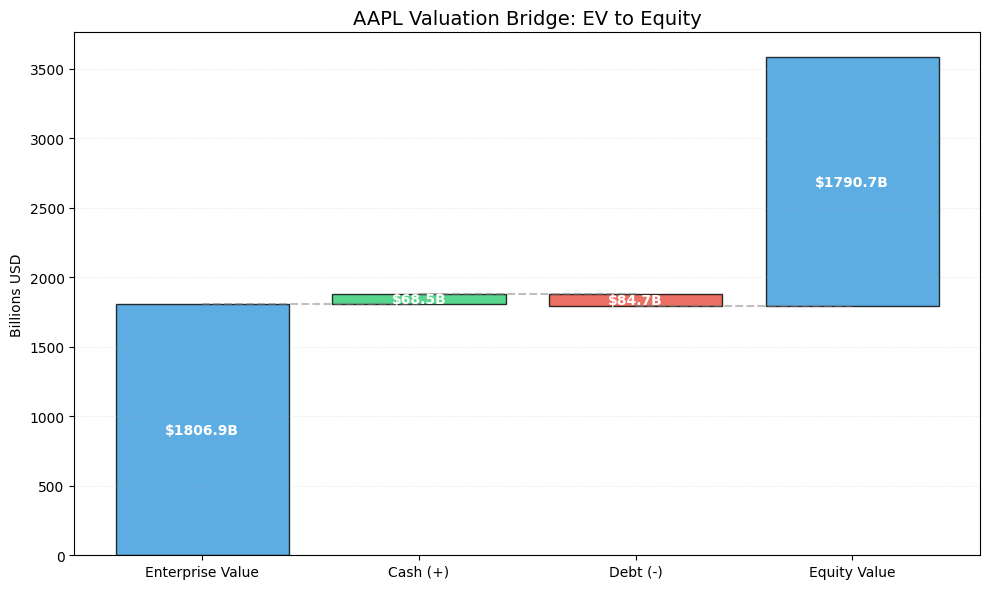

In [4]:
# 10. Additional Visualization: EV to Equity Value Bridge
import matplotlib.pyplot as plt

# Prepare bridge data
bridge_labels = ['Enterprise Value', 'Cash (+)', 'Debt (-)', 'Equity Value']
bridge_values = [ev/1e9, cash/1e9, -debt/1e9, equity_val/1e9]

# Calculate cumulative sum for block positioning
steps = [0] + list(np.cumsum(bridge_values))

plt.figure(figsize=(10, 6))

for i in range(len(bridge_values)):
    color = '#3498db' if i == 0 or i == 3 else ('#2ecc71' if bridge_values[i] > 0 else '#e74c3c')
    # Draw main rectangle
    plt.bar(bridge_labels[i], bridge_values[i], bottom=steps[i], color=color, edgecolor='black', alpha=0.8)

    # Add text label
    label_pos = steps[i] + bridge_values[i]/2
    plt.text(i, label_pos, f'${abs(bridge_values[i]):.1f}B', ha='center', va='center', fontweight='bold', color='white')

# Connector lines
for i in range(len(bridge_values) - 1):
    plt.plot([i, i + 1], [steps[i+1], steps[i+1]], color='gray', linestyle='--', alpha=0.5)

plt.title(f"{ticker} Valuation Bridge: EV to Equity", fontsize=14)
plt.ylabel("Billions USD")
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

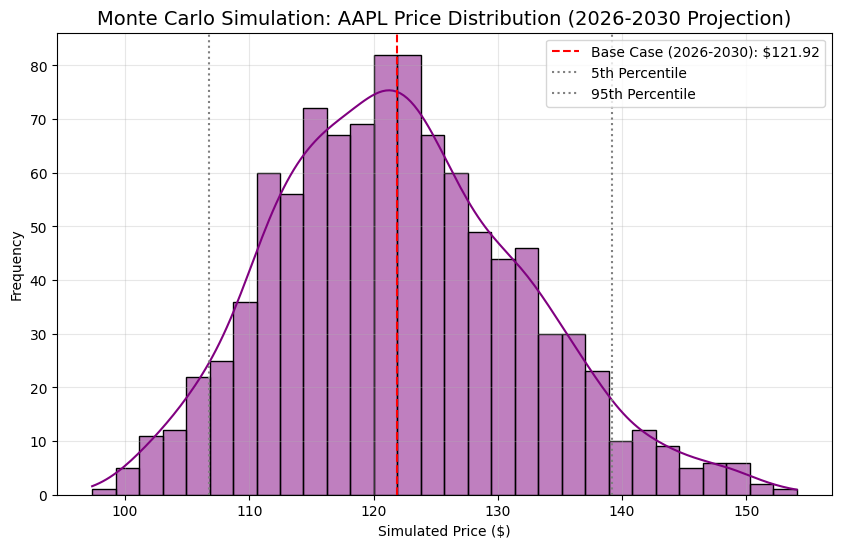

In [5]:
# 11. Advanced Visualization: Monte Carlo Simulation for Share Price
iterations = 1000
sim_prices = []

# Simulate random variations in growth and WACC
np.random.seed(42)
sim_growth = np.random.normal(rev_growth, 0.01, iterations)
sim_wacc = np.random.normal(wacc, 0.005, iterations)

for i in range(iterations):
    # FCF forecast for each iteration (period 2026-2030)
    temp_fcf = []
    temp_rev = revenue[-1] # 2025 base year
    for _ in range(proj_period):
        temp_rev *= (1 + sim_growth[i])
        temp_fcf.append(compute_fcf(temp_rev * ebita_margin, tax_rate, dep_amort[-1], capex[-1], 0))

    # Value calculation
    if sim_wacc[i] > 0.02:
        s_ev = compute_dcf_value(temp_fcf, sim_wacc[i], 0.02)
        s_price = (s_ev - debt + cash) / shares
        sim_prices.append(s_price)

# Distribution visualization
plt.figure(figsize=(10, 6))
sns.histplot(sim_prices, kde=True, color='purple', bins=30)
plt.axvline(price, color='red', linestyle='--', label=f'Base Case (2026-2030): ${price:.2f}')
plt.axvline(np.percentile(sim_prices, 5), color='gray', linestyle=':', label='5th Percentile')
plt.axvline(np.percentile(sim_prices, 95), color='gray', linestyle=':', label='95th Percentile')

plt.title(f"Monte Carlo Simulation: {ticker} Price Distribution (2026-2030 Projection)", fontsize=14)
plt.xlabel("Simulated Price ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

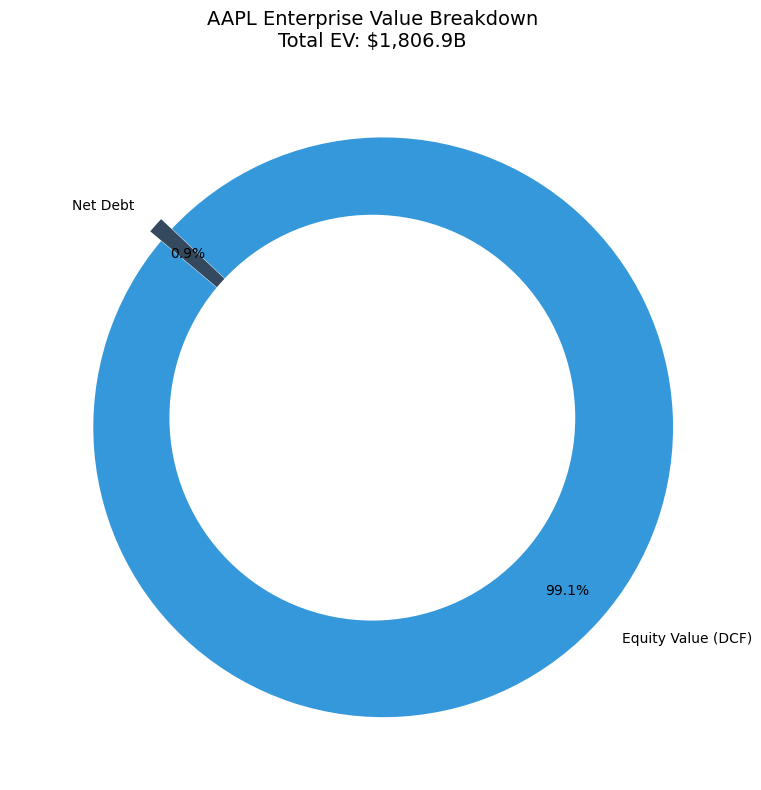

In [6]:
# 12. Visualization: Enterprise Value Composition (Donut Chart)
plt.figure(figsize=(8, 8))

net_debt = debt - cash

# Data preparation
if net_debt > 0:
    names = ['Equity Value (DCF)', 'Net Debt']
    values = [equity_val, net_debt]
    colors = ['#3498db', '#34495e']
else:
    names = ['Equity Value (DCF)', 'Net Cash (Excess)']
    values = [equity_val, abs(net_debt)]
    colors = ['#3498db', '#2ecc71']

# Plotting
plt.pie(values, labels=names, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85, explode=[0.05, 0])

# White circle in the center for donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f"{ticker} Enterprise Value Breakdown\nTotal EV: ${ev/1e9:,.1f}B", fontsize=14)
plt.tight_layout()
plt.show()

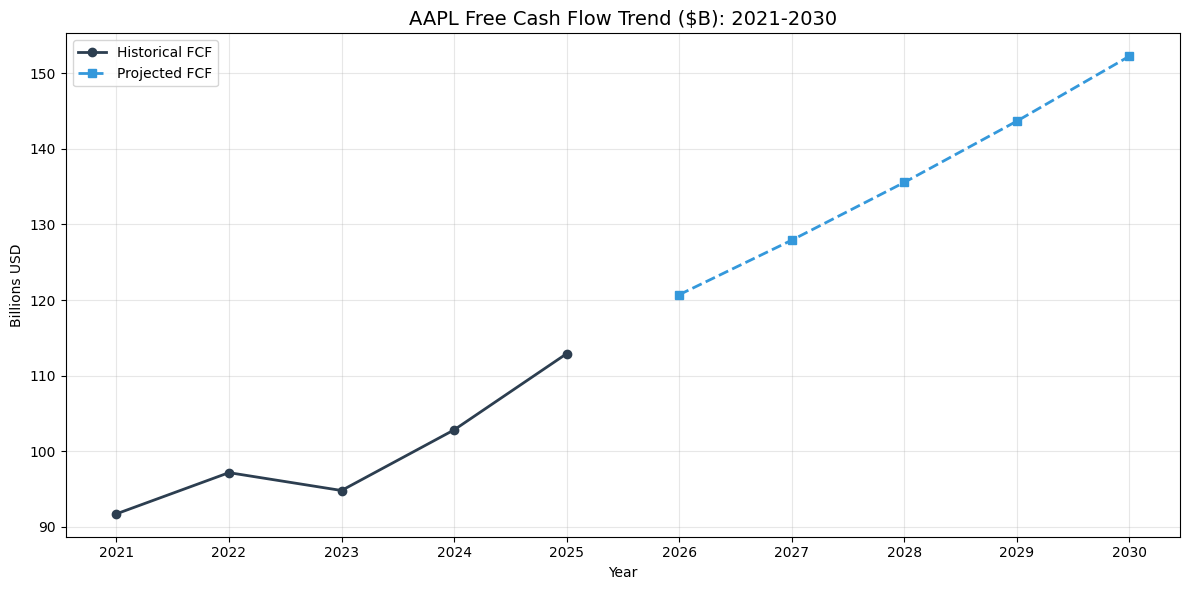

In [7]:
# 13. Visualization: Historical FCF vs Forecast
hist_years = [2021, 2022, 2023, 2024, 2025]
proj_years = [2026, 2027, 2028, 2029, 2030]

plt.figure(figsize=(12, 6))

# Historical data
plt.plot(hist_years, [f/1e9 for f in historical_fcf], marker='o', linestyle='-', color='#2c3e50', label='Historical FCF', linewidth=2)

# Projected data
plt.plot(proj_years, [f/1e9 for f in fcf_proj], marker='s', linestyle='--', color='#3498db', label='Projected FCF', linewidth=2)

# Styling
plt.title(f"{ticker} Free Cash Flow Trend ($B): 2021-2030", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Billions USD")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(hist_years + proj_years)
plt.tight_layout()
plt.show()

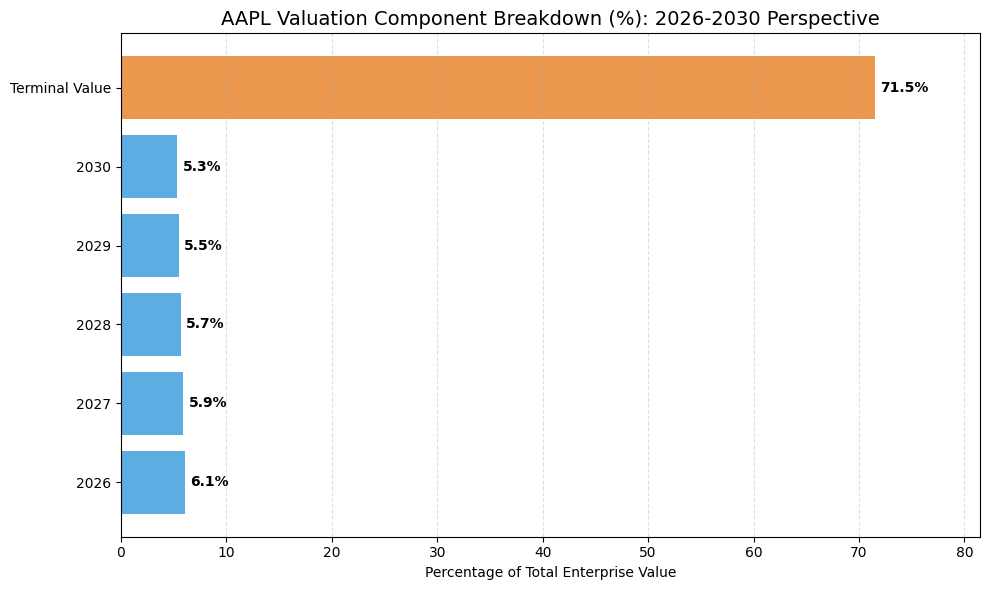

In [8]:
# 14. Visualization: Forecast Period Contribution to Enterprise Value
plt.figure(figsize=(10, 6))

# Data preparation
contributions = [f/(1+wacc)**(i+1) for i, f in enumerate(fcf_proj)]
contributions.append(TV_pv)
labels = [f'{y}' for y in range(2026, 2031)] + ['Terminal Value']
percentages = [c/ev * 100 for c in contributions]

# Horizontal chart
y_pos = np.arange(len(labels))
plt.barh(y_pos, percentages, color=['#3498db']*len(fcf_proj) + ['#e67e22'], alpha=0.8)
plt.yticks(y_pos, labels)

# Adding labels
for i, v in enumerate(percentages):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.title(f"{ticker} Valuation Component Breakdown (%): 2026-2030 Perspective", fontsize=14)
plt.xlabel("Percentage of Total Enterprise Value")
plt.xlim(0, max(percentages) + 10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

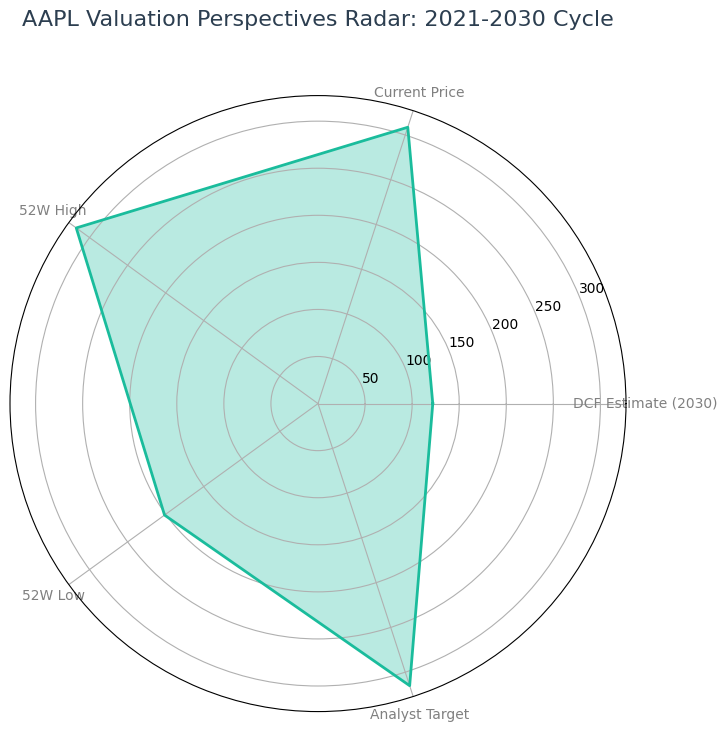

In [9]:
# 15. Final Visualization: Valuation Perspectives Radar Chart
from math import pi

# Data preparation
high_52 = info.get('fiftyTwoWeekHigh', current_price * 1.1)
low_52 = info.get('fiftyTwoWeekLow', current_price * 0.9)
target_mean = info.get('targetMeanPrice', current_price)

categories = ['DCF Estimate (2030)', 'Current Price', '52W High', '52W Low', 'Analyst Target']
values = [price, current_price, high_52, low_52, target_mean]

# Close the circle for the radar chart
values_radar = values + [values[0]]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Draw axes
plt.xticks(angles[:-1], categories, color='grey', size=10)

# Plot data
ax.plot(angles, values_radar, linewidth=2, linestyle='solid', color='#1abc9c')
ax.fill(angles, values_radar, '#1abc9c', alpha=0.3)

plt.title(f"{ticker} Valuation Perspectives Radar: 2021-2030 Cycle", size=16, color='#2c3e50', y=1.1)
plt.show()

### 16. Final Conclusion on AAPL Valuation (2021-2030)

Based on the Discounted Cash Flow (DCF) model constructed, the following key conclusions can be drawn:

1.  **Fair Value vs Market:**
    *   The estimated share price is approximately **$122.93**, while the current market price is at **$283.78**.
    *   The model indicates significant **overvaluation** (a market premium of about 56.7%) given the conservative growth rates (6%) and discount rate (WACC ~9.5%).

2.  **Value Structure:**
    *   More than **70%** of the company's value (Terminal Value) comes from the period after 2030. This makes the valuation extremely sensitive to long-term growth expectations and macroeconomic stability.
    *   The bridge analysis shows that Apple's net debt is minimal compared to its capitalization, confirming exceptional financial stability.

3.  **Risk Analysis (Monte Carlo):**
    *   The simulation of 1000 scenarios confirms that even with volatility in growth rates and WACC, most likely outcomes are distributed below the current market price. This suggests the market may be pricing in much more aggressive growth rates or significant revenue from new services/products not captured in the base forecast.

4.  **Summary:**
    The current DCF valuation suggests a cautious outlook on the asset. Investors should consider what drivers might allow the company to exceed the projected 6% revenue growth to justify current market valuations.